In [2]:
import os
import sys
import joblib

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, random_split, TensorDataset

from utils.models import build_model
from utils.preprocessing import (
    balance_dataset,
    FEATURES
)
from utils.evaluation import evaluate_model
from property_factory import build_properties
import property_driven_ml.logics as pml_logics

In [3]:
# =========================
# Define datasets
# =========================
# df_cicids_combined = df = pd.read_csv("../data/cicids_combined_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = df = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
DATASETS = {
    # "cicids_combined": {"data": df_cicids_combined},
    "ciciot2023": {"data": df_ciciot2023},
}

In [5]:
MODEL_TYPE = "mlp"
BATCH_SIZE = 256
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
TEST_SIZE = 0.3
LAMBDA_PROP = 0.3
WINDOW_SECONDS = 5.0


TRAINING ON: CICIOT2023
Shape: (4285835, 48)
label
DOS_HTTP_FLOOD    1508589
ATTACK            1187082
DDOS_SYN_FLOOD     741270
BENIGN             342255
DDOS_UDP_FLOOD     290106
PORTSCAN           216533
Name: count, dtype: int64
Features: 35
['proto', 'service', 'duration', 'orig_bytes', 'resp_bytes', 'conn_state', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'valid_tcp_handshake_feature', 'is_http', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_udp', 'udp_conn_count', 'udp_packets', 'udp_rate', 'unique_src_ips', 'syn_duration', 'syn_conn_count', 'syn_count', 'syn_rate', 'half_open_count', 'source_ip_count']
Balanced training set shape: (909438, 35)
Balanced training label distribution:
 label
DOS_HTTP_FLOOD    151573
DDOS_UDP_FLOOD    151573
PORTSCAN          151573
DDOS_SYN_FLOOD    151573
BENIGN            151573
A

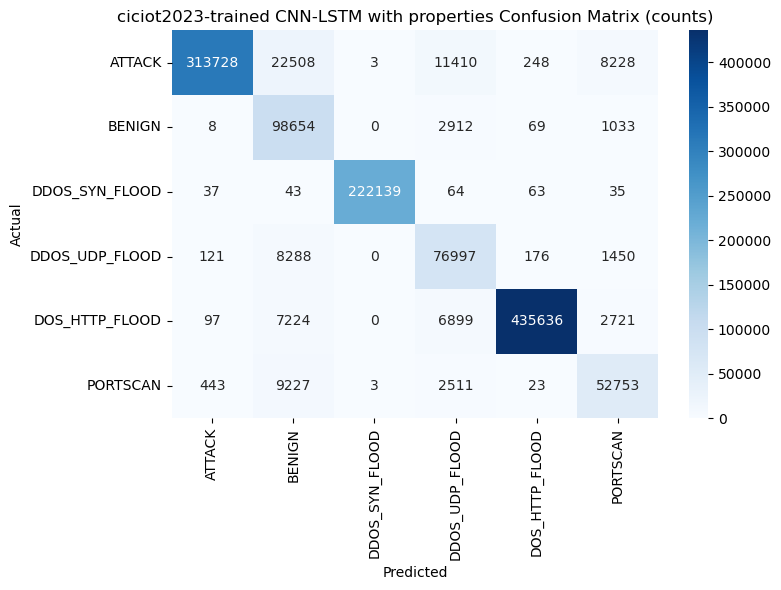


Saved model to: models/mlp_property_ciciot2023.joblib


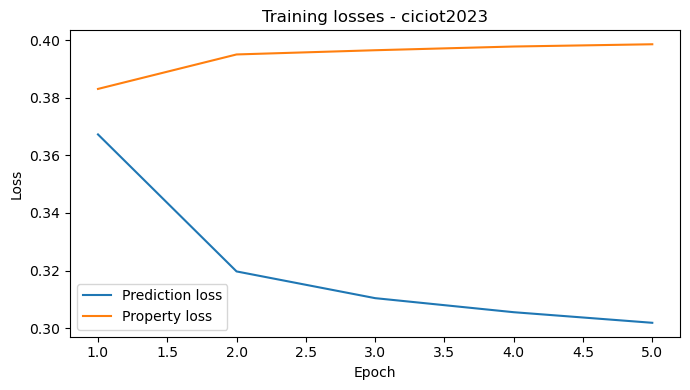

In [ ]:
for dataset_name, dataset_config in DATASETS.items():
    print("\n" + "=" * 70)
    print(f"TRAINING ON: {dataset_name.upper()}")
    print("=" * 70)

    df = dataset_config["data"].copy()

    feature_cols = [c for c in FEATURES if c in df.columns]

    print("Shape:", df.shape)
    print(df["label"].value_counts())
    print("Features:", len(feature_cols))
    print(feature_cols)

    X = df[feature_cols].copy()
    y = df["label"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=42,
    )

    X_train_balanced, y_train_balanced = balance_dataset(X_train, y_train)
    print("Balanced training set shape:", X_train_balanced.shape)
    print("Balanced training label distribution:\n", pd.Series(y_train_balanced).value_counts())

    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train_balanced)
    y_test_enc = label_encoder.transform(y_test)

    X_train_bal = X_train_balanced.copy()
    X_test_local = X_test.copy()

    categorical_cols = X_train_bal.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
    ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

    if len(categorical_cols) > 0:
        X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
        X_test_local[categorical_cols] = ordinal_encoder.transform(X_test_local[categorical_cols])

    binary_cols = [c for c in ["valid_tcp_handshake_feature", "is_udp", "is_http"] if c in feature_cols]
    continuous_cols = [c for c in feature_cols if c not in binary_cols]

    X_train_scaled_df = X_train_bal.copy()
    X_test_scaled_df = X_test_local.copy()

    scaler = StandardScaler()

    # Fit on ALL features
    X_train_scaled_df[feature_cols] = scaler.fit_transform(X_train_bal[feature_cols])
    X_test_scaled_df[feature_cols] = scaler.transform(X_test_local[feature_cols])

    # Restore binary columns to original 0/1 values
    for col in binary_cols:
        X_train_scaled_df[col] = X_train_bal[col].values
        X_test_scaled_df[col] = X_test_local[col].values

    # binary_cols are left untouched
    X_train_scaled = X_train_scaled_df[feature_cols].values
    X_test_scaled = X_test_scaled_df[feature_cols].values

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

    y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

    num_classes = len(label_encoder.classes_)
    model = build_model(
        model_type=MODEL_TYPE,
        n_features=len(feature_cols),
        num_classes=num_classes,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    properties = build_properties(
        device=device,
        scaler=scaler,
        feature_names=feature_cols,
        label_encoder=label_encoder,
        logic=pml_logics.DL2()
    )

    x_batch, _ = next(iter(train_loader))
    x_batch = x_batch.to(device)
    total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)

    print("Initial property loss: ", total_loss.item())
    print("Initial property sat: ", total_sat.item())
    print("Property stats:", prop_stats)

    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()

        pred_losses = []
        prop_losses = []
        last_stats = {}

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            logits = model(x_batch)
            pred_loss = criterion(logits, y_batch)

            total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)
            
            # For the first few epochs, focus on prediction loss to allow the model to learn basic patterns. 
            # After that, start incorporating the property loss to guide the model towards satisfying the properties.
            # if epoch < 3:
            #     loss = pred_loss
            # else:
            loss = pred_loss + LAMBDA_PROP * total_loss
            loss.backward()
            optimizer.step()

            pred_losses.append(pred_loss.item())
            prop_losses.append(total_loss.item())
            last_stats = prop_stats

        avg_pred_loss = float(np.mean(pred_losses))
        avg_prop_loss = float(np.mean(prop_losses))

        history.append({
            "epoch": epoch + 1,
            "pred_loss": avg_pred_loss,
            "prop_loss": avg_prop_loss,
            **last_stats,
        })

        print(
            f"Epoch {epoch+1:02d} | "
            f"pred_loss={avg_pred_loss:.4f} | "
            f"prop_loss={avg_prop_loss:.4f} | "
            f"{', '.join(f'{k}={v:.4f}' for k, v in last_stats.items())}"
        )

    # evaluation
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)

            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(y_batch.cpu().numpy())

    y_true_labels = label_encoder.inverse_transform(np.array(all_true))
    y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

    evaluate_model(
        y_true_labels,
        y_pred_labels,
        model_name=f"{dataset_name}-trained {MODEL_TYPE} with properties",
    )

    os.makedirs("models", exist_ok=True)
    save_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"

    joblib.dump(
        {
            "model": model.cpu(),
            "ordinal_encoder": ordinal_encoder,
            "scaler": scaler,
            "label_encoder": label_encoder,
            "features": feature_cols,
            "categorical_cols": list(categorical_cols),
        },
        save_path,
    )

    print(f"\nSaved model to: {save_path}")

    history_df = pd.DataFrame(history)
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["pred_loss"], label="Prediction loss")
    plt.plot(history_df["epoch"], history_df["prop_loss"], label="Property loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training losses - {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()